# NYC 311 Noise Complaints — Explainer Notebook

This notebook is the behind-the-scenes companion to our project website. It
documents how we loaded, cleaned, and analyzed NYC 311 noise complaint data,
and explains the choices behind the visualizations shown on the site.

**Dataset:** NYC 311 Service Requests, filtered to noise-related complaints and dates
(2018–2025), downloaded from NYC Open Data.

**Pipeline:** raw CSVs in `../data/raw/` → cleaned file written to
`../data/processed/311_noise_cleaned.csv` → used by the visualization team
for the website.

## Setup

Standard data science stack (pandas, matplotlib, seaborn). Warnings
suppressed globally to keep output clean. Paths are defined as constants
so anyone can edit them in one place if their local layout differs.

In [40]:
import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings globally
warnings.filterwarnings("ignore")

# Paths — edit if your local layout differs
DATA_DIR = "../data/raw"    # the two raw NYC 311 CSVs go here
OUT_DIR  = "../data/processed"   # cleaned output lands here
os.makedirs(OUT_DIR, exist_ok=True)

## Load and merge datasets

NYC Open Data publishes 311 service requests as two separate datasets:

- [311 Service Requests 2010–2019](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2010-to-2019/76ig-c548/about_data) 
- [311 Service Requests 2020–Present](https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data)

Two filters
were applied at export time:

- **Complaint Type** filtered to noise-related categories only
- **Created Date** between 2018-01-01 and 2025-12-31

After loading both CSV files, we merged them into a single dataframe. 

To reproduce, apply the same filters at both datasets, download as CSV, and save as:
- "311_Service_Requests_from_2018_to_2019_20260413.csv"
- "311_Service_Requests_from_2020_to_2025_20260413.csv"

finally, drop the two files into `../data/raw/`.

In [41]:
# Load both CSVs
file_path1 = os.path.join(DATA_DIR, "311_Service_Requests_from_2018_to_2019_20260413.csv")
file_path2 = os.path.join(DATA_DIR, "311_Service_Requests_from_2020_to_2025_20260413.csv")

df1 = pd.read_csv(file_path1)
df2 = pd.read_csv(file_path2)

# Merge both datasets
df = pd.concat([df1, df2], ignore_index=True)

## Clean and save dataset

We reduce the raw export to the columns we'll actually use and drop rows
that can't support our analysis. Four decisions we make:

1. **Keep 10 columns.** Timestamp, complaint type and detail, location
   type, borough, lat/long, and three street-level fields. The raw export
   has ~40 columns of administrative metadata (agency routing, closure
   timestamps, etc.) that we don't need for the analysis we are doing.
2. **Drop rows where Borough is "Unspecified" or null.** Our analysis
   groups by borough, so these rows can't contribute.
3. **Require coordinates.** Several planned visualizations are map-based,
   and complaints without latitude/longitude can't be placed.
4. **Drop duplicates.** Exact duplicates are rare in 311 data but cheap
   to remove as insurance.

We also parse `Created Date` into a proper datetime here so downstream
cells don't have to re-parse it.

The notebook assumes that the raw CSVs were exported
with the noise-type filter already applied at NYC Open Data. As a safety
net, an `assert` verifies that every complaint in the loaded data starts
with `"Noise"`. If someone re-exports the CSVs without the filter, the
notebook will fail loudly here rather than silently producing wrong
results downstream.

The cleaned file is saved to `../data/processed/311_noise_cleaned.csv`.

In [42]:
# Keep only columns relevant to the analysis
cols_to_keep = [
    'Created Date',
    'Problem (formerly Complaint Type)',
    'Problem Detail (formerly Descriptor)',
    'Location Type',
    'Borough',
    'Latitude',
    'Longitude',
    # Optional street-level
    'Incident Address',
    'Cross Street 1',
    'Cross Street 2',
]
df = df[cols_to_keep]

# Safety net: confirm the export filter was actually applied.
# If this fails, someone exported the CSVs without the "Noise" filter.
assert df['Problem (formerly Complaint Type)'].str.contains('Noise', na=False, case=False).all(), \
    "Non-noise complaints found — check the export filter at NYC Open Data"

# Drop rows we can't analyze
df = df[(df['Borough'] != 'Unspecified') & (df['Borough'].notna())]
df = df.dropna(subset=['Latitude', 'Longitude'])
df = df.drop_duplicates()

# Parse date column once. Here, downstream cells rely on this
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')

# Save cleaned dataset
output_path = os.path.join(OUT_DIR, "311_noise_cleaned.csv")
df.to_csv(output_path, index=False)

## Basic Stats 

Before any analysis, we get a handle on what's in the dataset — its size,
shape, missingness, and the shape of its key distributions.

### a. Key points
After cleaning, we have ~5.5M noise complaints spanning 2018 through 2025.
Missingness is low on the fields we care about. `Location Type` is the
only column with meaningful missing data (~9%). That won't affect
borough or time-based analyses. All geographic and temporal fields
are complete.

In [43]:
# Basic shape
print(f"Rows:     {len(df):,}")
print(f"Columns:  {len(df.columns)}")
print(f"Range:    {df['Created Date'].min().date()} to {df['Created Date'].max().date()}")
print(f"Memory:   {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent': (missing / len(df) * 100).round(2)
})
print("\nMissing values by column:")
print(missing_df.to_string() if len(missing_df) else "(none)")

Rows:     5,461,420
Columns:  10
Range:    2018-01-01 to 2025-12-30
Memory:   2492 MB

Missing values by column:
                                      Missing  Percent
Location Type                          489036     8.95
Cross Street 1                          94156     1.72
Cross Street 2                          93242     1.71
Incident Address                        92600     1.70
Problem Detail (formerly Descriptor)        2     0.00


### b. Fundamental distributions

Four views of the cleaned data, answering the basic "what does this look like?" questions. Key takeaways:

- The **Bronx** leads by raw complaint count (1.52M), followed closely by Manhattan (1.44M) and Brooklyn (1.36M); Staten Island is barely visible (120K)
- **Residential noise** is the most common complaint type overall (~48% of complaints)
- Volume rose sharply around 2020 — we'll quantify this in the Data Analysis section
- Complaints peak late at night and on weekends, as expected for a nuisance-driven dataset

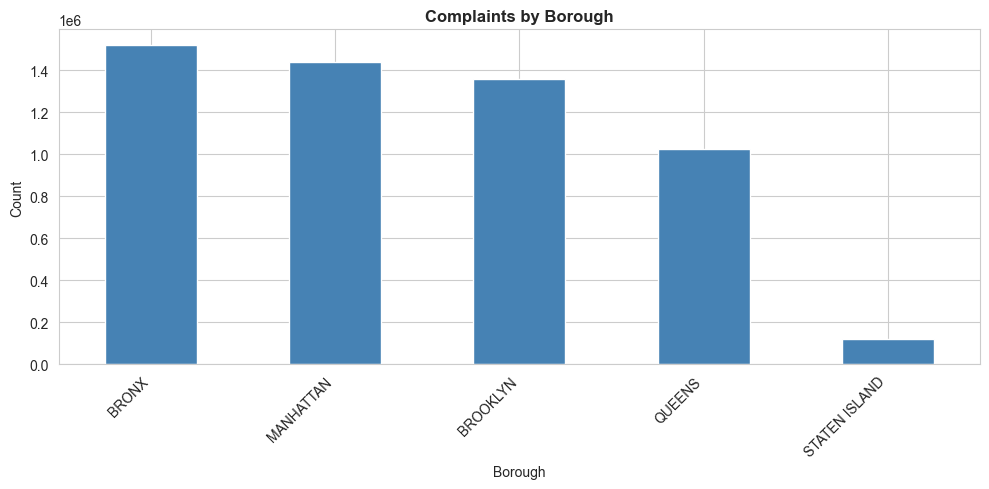

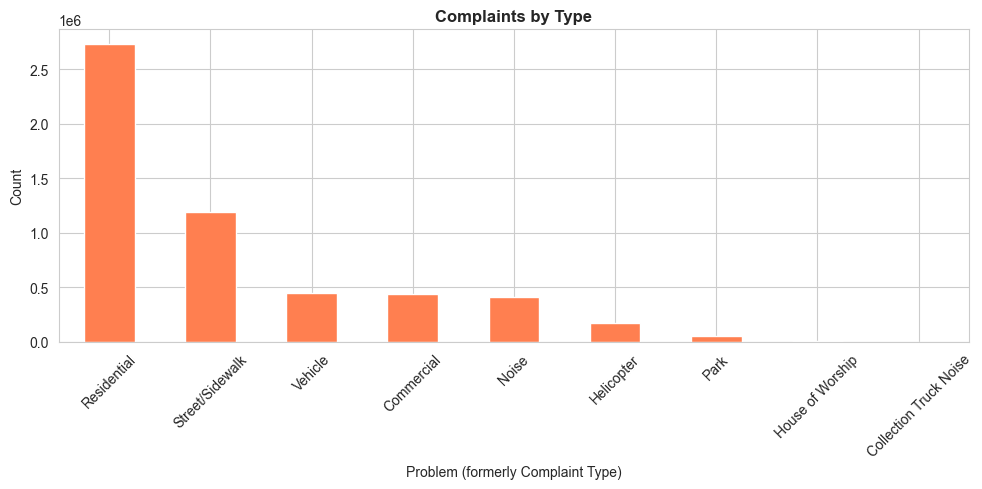

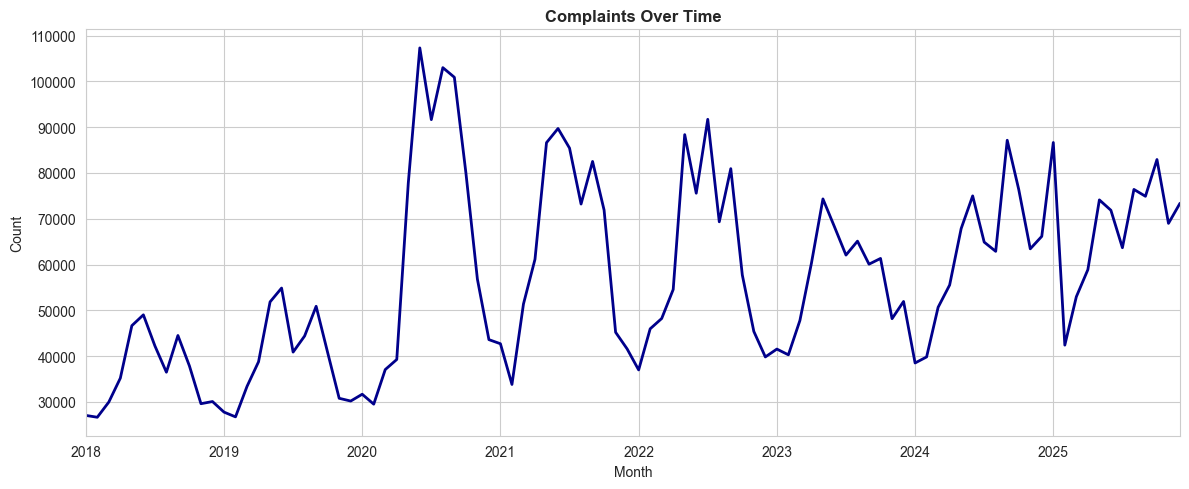

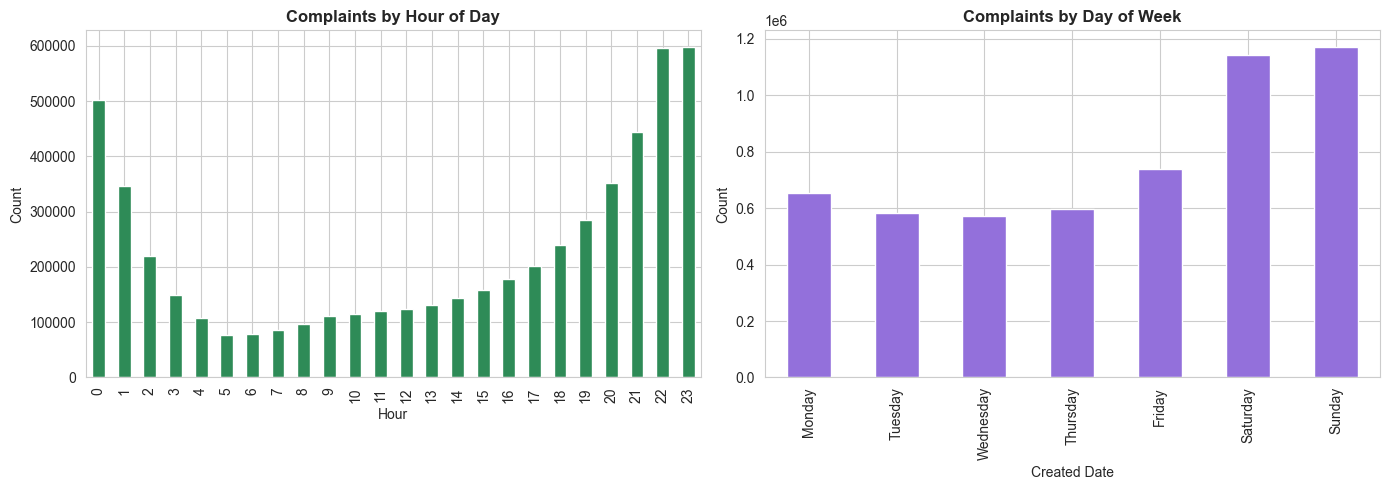

In [44]:
# Fundamental distributions
sns.set_style('whitegrid')

# Plot 1: Borough
fig, ax = plt.subplots(figsize=(10, 5))
df['Borough'].value_counts().plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Complaints by Borough', fontweight='bold', fontsize=12)
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot 2: Complaints by type
fig, ax = plt.subplots(figsize=(10, 5))
counts = df['Problem (formerly Complaint Type)'].value_counts()
counts.index = counts.index.str.replace(r'^Noise\s*-\s*', '', regex=True)
counts.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Complaints by Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Complaints over time
complaints_per_month = df['Created Date'].dt.to_period('M').value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 5))
complaints_per_month.plot(kind='line', ax=ax, color='darkblue', linewidth=2)
ax.set_title('Complaints Over Time', fontweight='bold', fontsize=12)
ax.set_ylabel('Count')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

# Plot 4: Hour-of-day and day-of-week
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Created Date'].dt.hour.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='seagreen')
axes[0].set_title('Complaints by Hour of Day', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Created Date'].dt.day_name().value_counts().reindex(day_order).plot(
    kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Complaints by Day of Week', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Data Analysis

Our website tells a story about **how NYC's noise varies across location, time,
and the COVID dividing line**. This section presents the four analytical
findings that story rests on. Each feeds directly into one or more
visualizations on the site.

Two of the questions (Q1 and parts of Q2) look at COVID's effect on the city's
soundscape. For those, we define three "eras":

- **Pre-COVID:** 2018-01-01 to 2020-02-29
- **Lockdown:** 2020-03-01 to 2021-06-30
- **Post-COVID:** 2021-07-01 to 2025-12-30

In [45]:
# Label each complaint by COVID era for use in the analyses below
def covid_era(d):
    if d < pd.Timestamp('2020-03-01'):
        return 'Pre-COVID'
    elif d < pd.Timestamp('2021-07-01'):
        return 'Lockdown'
    else:
        return 'Post-COVID'

df['Era'] = df['Created Date'].map(covid_era)

# 2020 US Census borough populations, used for per-capita rates in Q2
borough_pop = {
    'BRONX':         1_472_654,
    'BROOKLYN':      2_736_074,
    'MANHATTAN':     1_694_251,
    'QUEENS':        2_405_464,
    'STATEN ISLAND':   495_747,
}
print("Era labels added. Counts:")
print(df['Era'].value_counts())

Era labels added. Counts:
Era
Post-COVID    3390943
Lockdown      1102822
Pre-COVID      967655
Name: count, dtype: int64


### Q1 - Did COVID change NYC's noise?

Our headline question: did the pandemic leave a durable mark on the city's soundscape? We test it three ways..

1. How did monthly complaint volume change across the three eras?
2. Has the post-COVID level returned to baseline, or is the "new normal" higher?
3. Did the *mix* of complaint types shift, did residential noise rise while
   commercial/street noise fell?

Average complaints per month by era:
Era
Pre-COVID     37333
Lockdown      69074
Post-COVID    62824

Lockdown vs pre:   +85.0%
Post-COVID vs pre: +68.3%


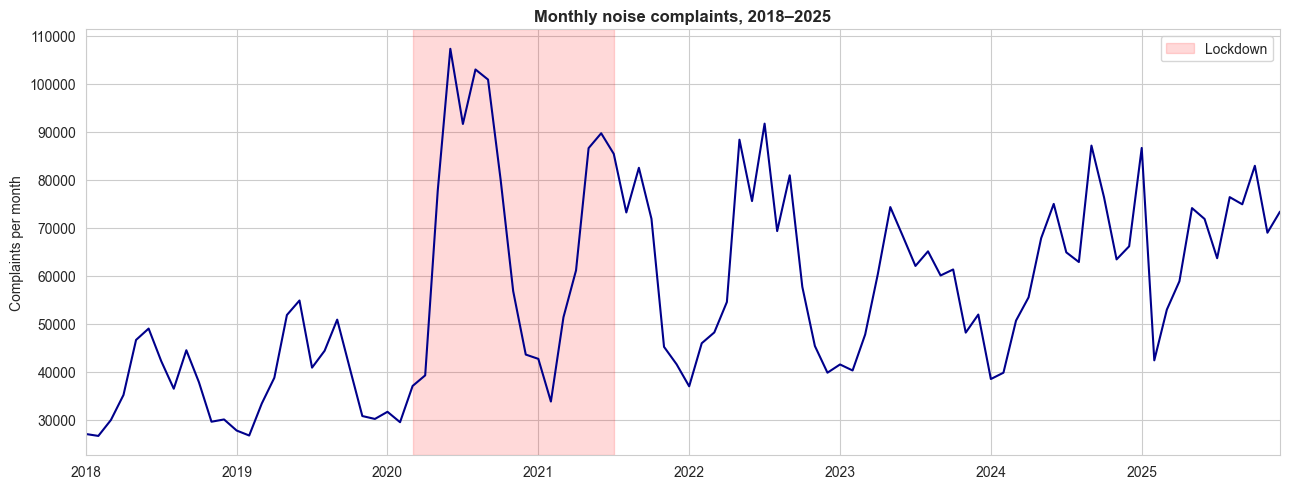


Complaint-type share (%) pre vs during lockdown:
Era                                Lockdown  Pre-COVID  Change (pp)
Problem (formerly Complaint Type)                                  
Noise - Street/Sidewalk                25.9       18.1          7.8
Noise - Vehicle                        10.7        8.3          2.4
Noise - Helicopter                      2.0        0.6          1.4
Noise - Park                            1.1        0.8          0.3
Collection Truck Noise                  0.0        0.0          0.0
Noise - House of Worship                0.1        0.2         -0.1
Noise - Residential                    49.3       50.1         -0.8
Noise - Commercial                      5.5        9.4         -3.9
Noise                                   5.4       12.6         -7.2


In [46]:
# 1 & 2: monthly complaint rate by era
monthly = df.set_index('Created Date').resample('MS').size()
era_monthly = df.groupby('Era').size() / df.groupby('Era')['Created Date'].apply(
    lambda s: (s.max() - s.min()).days / 30.44
)
era_monthly = era_monthly.round(0).astype(int).reindex(['Pre-COVID', 'Lockdown', 'Post-COVID'])

print("Average complaints per month by era:")
print(era_monthly.to_string())

pre = era_monthly['Pre-COVID']
lock = era_monthly['Lockdown']
post = era_monthly['Post-COVID']
print(f"\nLockdown vs pre:   {(lock/pre - 1)*100:+.1f}%")
print(f"Post-COVID vs pre: {(post/pre - 1)*100:+.1f}%")

# Plot the monthly series with era shading
fig, ax = plt.subplots(figsize=(13, 5))
monthly.plot(ax=ax, color='darkblue', linewidth=1.5)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-07-01'),
           alpha=0.15, color='red', label='Lockdown')
ax.set_title('Monthly noise complaints, 2018–2025', fontweight='bold')
ax.set_ylabel('Complaints per month')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

# 3: mix shift — top complaint types pre vs during lockdown
type_col = 'Problem (formerly Complaint Type)'
mix = (
    df[df['Era'].isin(['Pre-COVID', 'Lockdown'])]
    .groupby(['Era', type_col]).size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
    .T
    .round(1)
)
mix['Change (pp)'] = (mix['Lockdown'] - mix['Pre-COVID']).round(1)
mix = mix.sort_values('Change (pp)', ascending=False)
print("\nComplaint-type share (%) pre vs during lockdown:")
print(mix.to_string())

**Finding (Q1):** COVID's mark on NYC's noise is unmistakable and, importantly, *durable*.

- Pre-COVID, NYC logged an average of **37,300 noise complaints per month**. During lockdown (March 2020 - June 2021) that jumped to **69,100/month - an 85% increase**. And crucially, the city has *not* returned to baseline: the post-COVID average of **62,800/month still runs 68% above pre-pandemic levels**, five years later.
- The *mix* also shifted, but not in the direction we initially expected. Residential noise's share actually held roughly steady (50.1% → 49.3%). The big movers were **Street/Sidewalk noise (+7.8 percentage points)** and **Vehicle noise (+2.4 pp)**, which surged as outdoor activity replaced indoor venues. **Commercial noise fell sharply (-3.9 pp)** as bars, clubs, and offices closed. Helicopter complaints tripled their share (+1.4 pp), the NYPD's heavy surveillance of outdoor protests in 2020 is a plausible driver.

### Q2 - Which boroughs are noisiest and with what kind of noise?

Raw complaint counts can mislead because boroughs differ enormously in size.
Brooklyn has ~5.5× the population of Staten Island, so we'd expect ~5.5× the
complaints even if both were equally loud per person. We look at **per-capita
complaint rates** and at the **complaint-type composition** of each borough.

Noise complaints per 1,000 residents (2018–2025 total):
               Complaints  Population  Per 1,000 residents
Borough                                                   
BRONX             1518408     1472654                 1031
MANHATTAN         1438048     1694251                  849
BROOKLYN          1360173     2736074                  497
QUEENS            1024790     2405464                  426
STATEN ISLAND      120001      495747                  242

Top 3 complaint types per borough (% share):
Borough        Problem (formerly Complaint Type)
BRONX          Noise - Residential                  63.7
               Noise - Street/Sidewalk              22.1
               Noise - Vehicle                       7.5
BROOKLYN       Noise - Residential                  50.0
               Noise - Street/Sidewalk              20.4
               Noise - Commercial                   10.6
MANHATTAN      Noise - Residential                  33.8
               Noise - Street/Sidewal

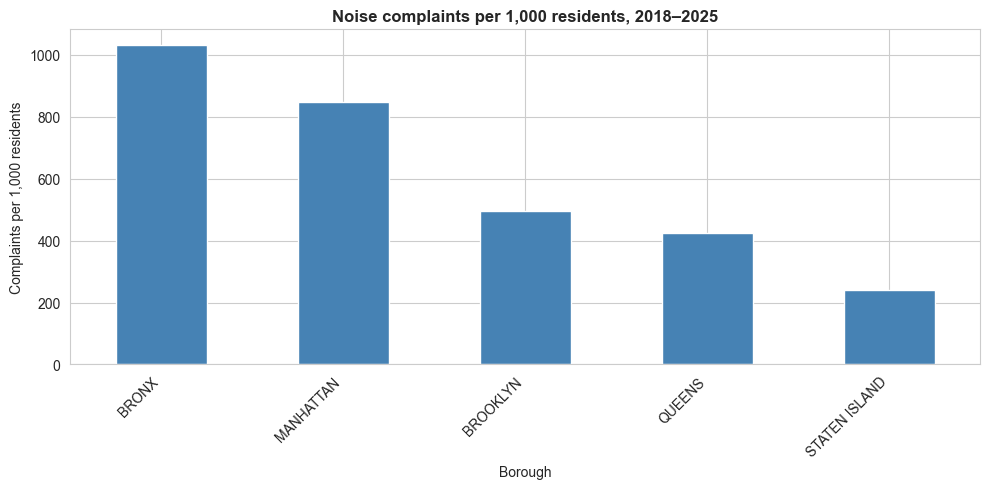

In [47]:
# Per-capita complaint rate by borough
borough_counts = df['Borough'].value_counts()
borough_df = pd.DataFrame({
    'Complaints': borough_counts,
    'Population': [borough_pop[b] for b in borough_counts.index],
})
borough_df['Per 1,000 residents'] = (
    borough_df['Complaints'] / borough_df['Population'] * 1000
).round(0).astype(int)
borough_df = borough_df.sort_values('Per 1,000 residents', ascending=False)
print("Noise complaints per 1,000 residents (2018–2025 total):")
print(borough_df.to_string())

# Complaint-type composition per borough — top 3 types per borough
type_col = 'Problem (formerly Complaint Type)'
by_bor = (
    df.groupby(['Borough', type_col]).size()
    .groupby(level=0, group_keys=False)
    .apply(lambda s: (s / s.sum() * 100).round(1).nlargest(3))
)
print("\nTop 3 complaint types per borough (% share):")
print(by_bor.to_string())

# Plot: per-capita bar chart
fig, ax = plt.subplots(figsize=(10, 5))
borough_df['Per 1,000 residents'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Noise complaints per 1,000 residents, 2018–2025',
             fontweight='bold')
ax.set_ylabel('Complaints per 1,000 residents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding (Q2):** Raw totals and per-capita rates tell very different stories.

The **Bronx leads in both raw count (1.52M) and per-capita rate (1,031 complaints per 1,000 residents)**. That means every Bronx resident "generates" roughly one complaint per year on average. **Manhattan is second (849 per 1,000)**, despite being only the third-largest borough by population. The real surprise is Brooklyn: it's NYC's most populous borough, but per capita it ranks fourth at 497, which is less than half the Bronx's rate. **Staten Island is by far the quietest (242 per 1,000)**, roughly a quarter of the Bronx's rate.

The *composition* also differs sharply:
- **Bronx** is the most residential-heavy (63.7% residential). Complaints are overwhelmingly about neighbors.
- **Manhattan** has the most diverse mix, with residential at only 33.8% and street/sidewalk noise a very close second at 28.3%, consistent with its commercial, tourist-heavy character.
- **Queens and Staten Island** look structurally similar to the Bronx, i.e. residential-dominant.

This tells us borough-level maps need to be **normalized by population** to avoid simply showing a map of where people live, and that "loud" means genuinely different things in different boroughs. The finding drives **The Main Event** (interactive choropleth map), and the type-mix numbers feed **The Neighborhood Showdown** (radar charts comparing borough profiles).

### Q3 - When is NYC loudest? Day-of-week × hour, and seasonality

The Basic Stats plots showed day-of-week and hour-of-day distributions
separately. The more interesting pattern sits in their *interaction*,
Friday at 2 AM is not Monday at 2 AM. We cross the two into a heatmap,
then split that heatmap by COVID era to see whether the weekly rhythm
itself changed during the pandemic. We also look at seasonal
(month-of-year) patterns across the full date range.

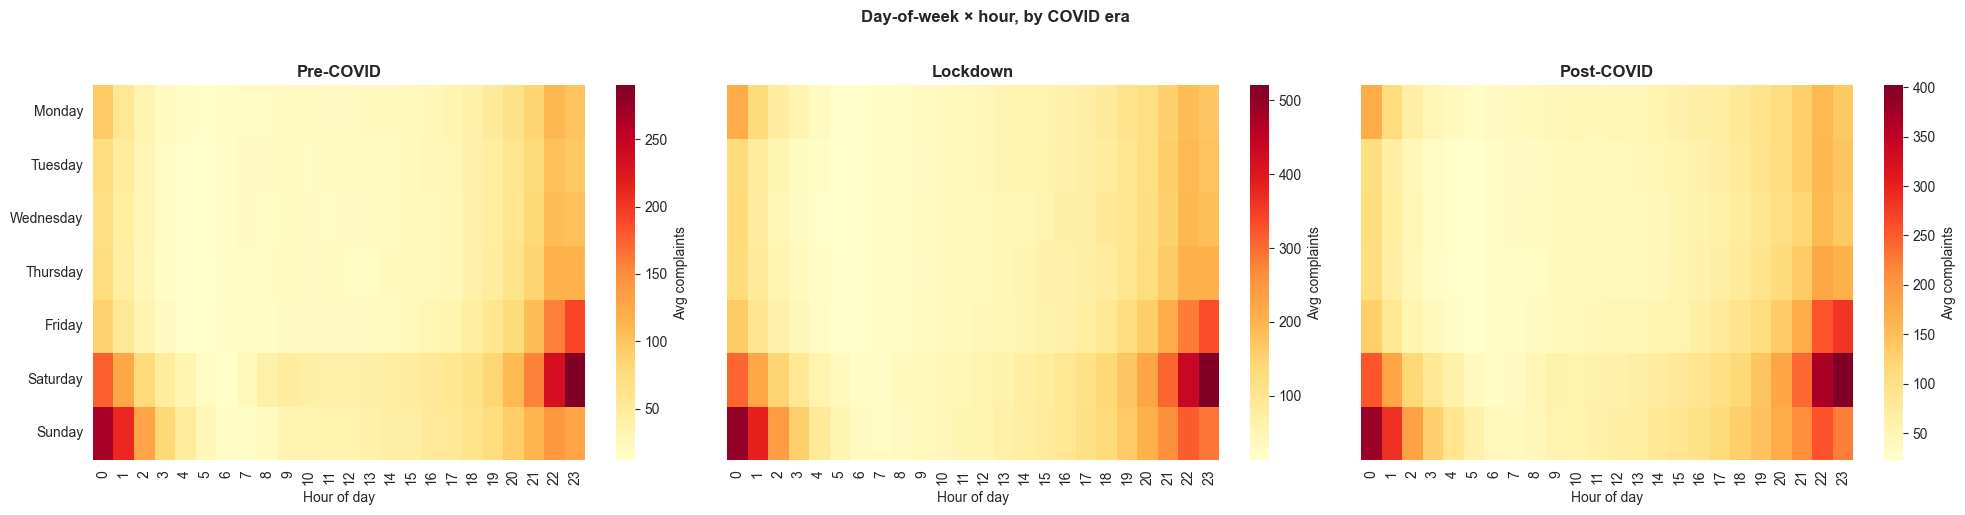

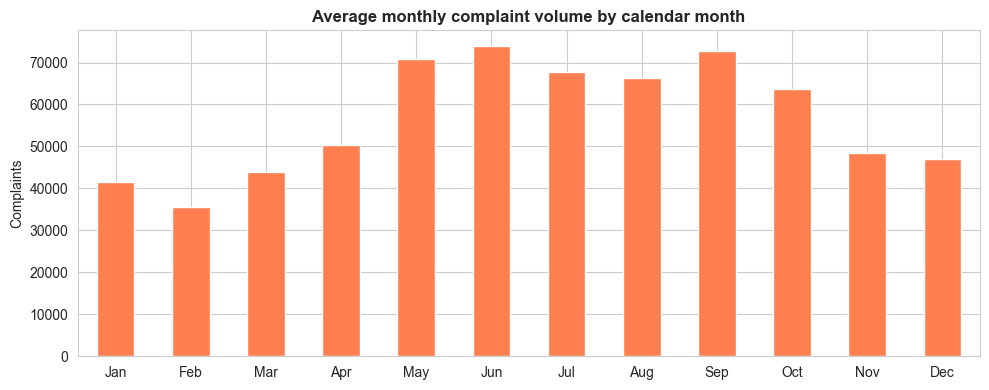

Seasonal ratio: peak month (Jun) has 2.07x the complaints of quietest month (Feb).
Weekend midnight-3am hours get 3.25x the complaints of weekday midnight-3am hours.


In [48]:
# Day-of-week × hour, split by COVID era
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
for ax, era in zip(axes, ['Pre-COVID', 'Lockdown', 'Post-COVID']):
    era_df = df[df['Era'] == era]
    heatmap = (
        era_df.assign(
            dow=era_df['Created Date'].dt.day_name(),
            hour=era_df['Created Date'].dt.hour,
        )
        .pivot_table(index='dow', columns='hour', values='Borough',
                     aggfunc='count', fill_value=0)
        .reindex(day_order)
    )
    # Normalize to complaints per day so the three eras are comparable
    n_days = (era_df['Created Date'].max() - era_df['Created Date'].min()).days
    heatmap = heatmap / n_days * 7  # avg per weekday slot

    sns.heatmap(heatmap, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Avg complaints'})
    ax.set_title(f'{era}', fontweight='bold')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('')

plt.suptitle('Day-of-week × hour, by COVID era', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Seasonality: complaints by month-of-year
monthly_avg = (
    df.groupby(df['Created Date'].dt.month).size() /
    df['Created Date'].dt.year.nunique()
).round(0).astype(int)
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
monthly_avg.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Average monthly complaint volume by calendar month',
             fontweight='bold')
ax.set_ylabel('Complaints')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Seasonal ratio: peak month ({monthly_avg.idxmax()}) has "
      f"{monthly_avg.max() / monthly_avg.min():.2f}x the complaints of "
      f"quietest month ({monthly_avg.idxmin()}).")

# Quantify the weekend-night ridge
weekend_late = df[(df['Created Date'].dt.day_name().isin(['Saturday', 'Sunday'])) &
                  (df['Created Date'].dt.hour.isin([0, 1, 2, 3]))]
weekday_late = df[(df['Created Date'].dt.day_name().isin(['Tuesday', 'Wednesday', 'Thursday'])) &
                  (df['Created Date'].dt.hour.isin([0, 1, 2, 3]))]
ratio = (len(weekend_late) / 2) / (len(weekday_late) / 3)  # per-day normalization
print(f"Weekend midnight-3am hours get {ratio:.2f}x the complaints of weekday midnight-3am hours.")

**Finding (Q3):** NYC has two distinct noise rhythms: a weekly one and a seasonal one. The weekly rhythm's *shape* persisted through COVID, but its *intensity* did not.

- **Weekly:** a strong late-night weekend ridge. Weekend midnight–3 AM hours get **3.25× the complaints per hour of equivalent weekday hours**, consistent with party and nightlife noise. Weekday hours are much flatter, with only a mild evening uptick from ~8–11 PM.
- **COVID amplified the rhythm but didn't reshape it.** All three eras show the same pattern — hottest at Saturday/Sunday midnight–3 AM, cool through weekday daytime. What changed is intensity: Pre-COVID peaks around ~290 complaints per slot, Lockdown peaks near ~520 (roughly 1.8×), and Post-COVID still peaks around ~400. The city's *when* didn't change; its *how much* did. This visually mirrors Q1's finding that complaint volume never returned to baseline.
- **Seasonal:** June is the peak month, with **2.07× the complaint volume of February**, the quietest. The pattern is clearly warm-weather driven: open windows, outdoor gatherings, rooftop parties, ice cream trucks. That matches our intuition that noise is something you notice more when you can't close a window against it.

### Q4 - Where are the hotspots?

Borough is too coarse a unit. Brooklyn alone spans 2.7 million people and
neighborhoods as different as Williamsburg and Bay Ridge. We aggregate the
complaints to a fine coordinate grid (rounded to 3 decimal places, roughly
a 100-meter cell) and identify the top hotspots.

In [49]:
# Round coordinates to ~100m grid and count complaints per cell
grid = (
    df.assign(
        lat_grid=df['Latitude'].round(3),
        lng_grid=df['Longitude'].round(3),
    )
    .groupby(['lat_grid', 'lng_grid', 'Borough'])
    .size()
    .reset_index(name='Complaints')
    .sort_values('Complaints', ascending=False)
)
print(f"{len(grid):,} distinct grid cells contain complaints.")
print(f"Top 15 hotspots over the full period:\n")
print(grid.head(15).to_string(index=False))

# How concentrated is the noise? What share of complaints comes from the top 1% of cells?
total = grid['Complaints'].sum()
top_1pct_cutoff = int(len(grid) * 0.01)
top_1pct_share = grid.head(top_1pct_cutoff)['Complaints'].sum() / total * 100
print(f"\nTop 1% of cells ({top_1pct_cutoff:,} cells) account for "
      f"{top_1pct_share:.1f}% of all complaints.")

55,543 distinct grid cells contain complaints.
Top 15 hotspots over the full period:

 lat_grid  lng_grid   Borough  Complaints
   40.892   -73.860     BRONX      249553
   40.892   -73.859     BRONX      142481
   40.722   -73.810    QUEENS       39357
   40.837   -73.904     BRONX       17387
   40.668   -73.847    QUEENS       12875
   40.700   -73.984  BROOKLYN       10070
   40.719   -73.804    QUEENS        9599
   40.824   -73.953 MANHATTAN        9366
   40.830   -73.866     BRONX        8969
   40.813   -73.946 MANHATTAN        8756
   40.832   -73.929     BRONX        7755
   40.783   -73.840    QUEENS        7190
   40.742   -73.980 MANHATTAN        6876
   40.864   -73.921 MANHATTAN        6866
   40.862   -73.911     BRONX        6767

Top 1% of cells (555 cells) account for 27.5% of all complaints.


**Finding (Q4):** NYC's noise is extraordinarily concentrated. The top 1% of ~100m grid cells (just 555 cells out of 55,543) account for **27.5% of all complaints**.

However, the top of the list comes with a strong caveat. The single loudest grid cell (40.892, -73.860 in the Bronx) has **249,553 complaints**, and the second cell (40.892, -73.859), essentially the same location, ~85m away, adds another 142,481. Together, these two adjacent cells produce 7.2% of the entire dataset. **This is almost certainly not a real noise hotspot but a coordinate artifact**. Either it's a default coordinate assigned by 311 when an address can't be geocoded, or a single large residential complex generating disproportionate reports.

Setting that anomaly aside, the real hotspot pattern is instructive: the top cells are split across all four major boroughs, showing noise concentration isn't a single-borough phenomenon.

## Genre

*(To be written — which genre we used
and why)*

## Visualizations

*(To be written after the viz team finishes the website — explain
the chosen visualizations and why they suit the story.)*

## Discussion

*(To be written — what went well, what's missing, what could be
improved.)*

## Contributions

*(To be written — who did what.)*